# Neural Network Demo

Logistic Regression + Binary Cross-Entropy Loss + Gradient Descent

Based on *The Hundred-Page Machine Learning Book* — Andriy Burkov

---

**Goal:** Predict whether a customer will make a purchase (label = 0 or 1)  
**Features:** Age (years) and Salary (USD thousands)  
**Architecture:** 1 linear layer + sigmoid activation = logistic regression  


---
## Setup

In [54]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

torch.manual_seed(42)
model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

inputs = torch.tensor([
    [22, 25], [25, 35], [47, 80], [52, 95], [46, 82], [56, 90],
    [23, 27], [30, 50], [40, 60], [39, 47], [53, 95], [48, 88]
], dtype=torch.float32)

labels = torch.tensor([
    [0], [0], [1], [1], [1], [1],
    [0], [1], [1], [0], [1], [1]
], dtype=torch.float32)


X = inputs.numpy()   # (12, 2)
W = model[0].weight.data.numpy()   # shape (1, 2)  — as stored by PyTorch
b = model[0].bias.data.numpy()     # shape (1,)
Yhat = 1 / (1 + np.exp(-Z))


df_X = pd.DataFrame(X, columns=['age (x₁)', 'salary (x₂)'],
                    index=[f'customer {i+1}' for i in range(12)])

df_W = pd.DataFrame(W, columns=['w₁ (age)', 'w₂ (salary)'],
                    index=['output neuron'])

df_WT = pd.DataFrame(W.T, index=['w₁ (age)', 'w₂ (salary)'],
                     columns=['output neuron'])

df_b = pd.DataFrame({'bias': b}, index=['value'])

df_Yhat = pd.DataFrame(Yhat, columns=['ŷ (purchase prob)'],
                       index=[f'customer {i+1}' for i in range(12)])


## Dataset visualization

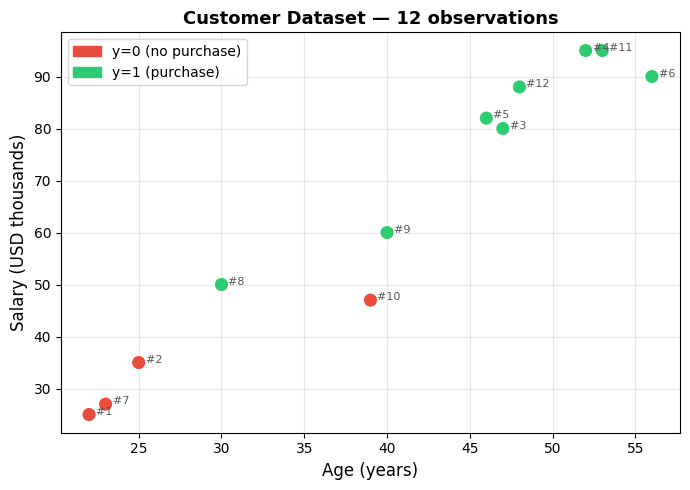

💡 Notice: higher salary + higher age → more likely to purchase


In [55]:
fig, ax = plt.subplots(figsize=(7, 5))
X_np = inputs.numpy()
y_np = labels.numpy().ravel()

colors = ['#e74c3c' if yi == 0 else '#2ecc71' for yi in y_np]
ax.scatter(X_np[:, 0], X_np[:, 1], c=colors,
           s=120, edgecolors='white', linewidths=1.5, zorder=3)
for i, xi in enumerate(X_np):
    ax.annotate(f'  #{i+1}', xy=xi, fontsize=8, color='#555')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Salary (USD thousands)', fontsize=12)
ax.set_title('Customer Dataset — 12 observations', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(handles=[mpatches.Patch(color='#e74c3c', label='y=0 (no purchase)'),
                   mpatches.Patch(color='#2ecc71', label='y=1 (purchase)')], loc='upper left')
plt.tight_layout(); plt.show()
print('💡 Notice: higher salary + higher age → more likely to purchase')

## NN Architecture


Paper diagram

```
INPUT LAYER          COMPUTATION            OUTPUT LAYER
(2 features)                                (1 neuron)

   x₁ (age)    ──── w₁ ────┐
                            ├──→ z = w₁x₁ + w₂x₂ + b ──→ σ(z) ──→ ŷ
   x₂ (salary) ──── w₂ ────┘
                       b ──────────────────────────────────↑
```

**Parameters to learn:** w = [w₁, w₂] (shape 2×1) and bias b  
**Total learnable parameters = 3**


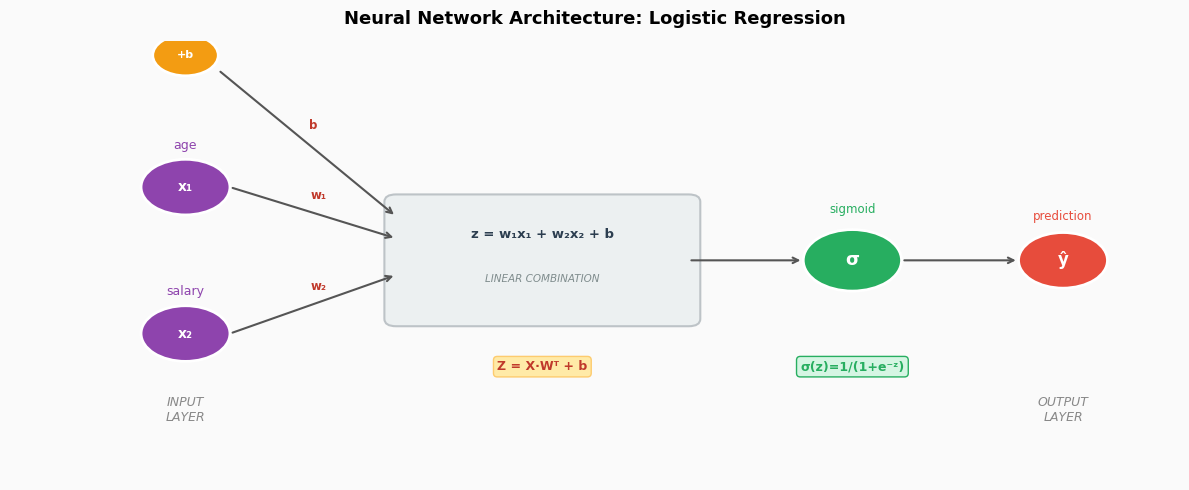

In [56]:
#  @title Diagram
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
fig.patch.set_facecolor('#fafafa'); ax.set_facecolor('#fafafa')

def draw_neuron(ax, x, y, label, color='#3498db', r=0.38, fontsize=10):
    ax.add_patch(Circle((x, y), r, color=color, zorder=3, linewidth=2, ec='white'))
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555', lw=1.5):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        ax.text((x1+x2)/2+0.05, (y1+y2)/2+0.15, label,
                ha='center', va='bottom', fontsize=8.5, color='#c0392b', fontweight='bold')

draw_neuron(ax, 1.5, 4.0, 'x₁', color='#8e44ad')
draw_neuron(ax, 1.5, 2.0, 'x₂', color='#8e44ad')
ax.text(1.5, 4.52, 'age', ha='center', fontsize=9, color='#8e44ad')
ax.text(1.5, 2.52, 'salary', ha='center', fontsize=9, color='#8e44ad')
ax.text(1.5, 0.8, 'INPUT\nLAYER', ha='center', fontsize=9, color='#888', style='italic')

rect = mpatches.FancyBboxPatch((3.3, 2.2), 2.5, 1.6,
    boxstyle='round,pad=0.1', fc='#ecf0f1', ec='#bdc3c7', lw=1.5, zorder=2)
ax.add_patch(rect)
ax.text(4.55, 3.35, 'z = w₁x₁ + w₂x₂ + b', ha='center', va='center',
        fontsize=9.5, fontweight='bold', color='#2c3e50')
ax.text(4.55, 2.75, 'LINEAR COMBINATION', ha='center', va='center',
        fontsize=7.5, color='#7f8c8d', style='italic')
ax.text(4.55, 1.5, 'Z = X·Wᵀ + b', ha='center', fontsize=9, color='#c0392b',
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='#ffeaa7', ec='#fdcb6e'))

draw_neuron(ax, 7.2, 3.0, 'σ', color='#27ae60', r=0.42, fontsize=13)
ax.text(7.2, 3.65, 'sigmoid', ha='center', fontsize=8.5, color='#27ae60')
ax.text(7.2, 1.5, 'σ(z)=1/(1+e⁻ᶻ)', ha='center', fontsize=9, color='#27ae60',
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='#d5f5e3', ec='#27ae60'))

draw_neuron(ax, 9.0, 3.0, 'ŷ', color='#e74c3c', r=0.38, fontsize=12)
ax.text(9.0, 3.55, 'prediction', ha='center', fontsize=8.5, color='#e74c3c')
ax.text(9.0, 0.8, 'OUTPUT\nLAYER', ha='center', fontsize=9, color='#888', style='italic')

draw_neuron(ax, 1.5, 5.8, '+b', color='#f39c12', r=0.28, fontsize=8)
draw_arrow(ax, 1.88, 4.0, 3.3, 3.3, 'w₁')
draw_arrow(ax, 1.88, 2.0, 3.3, 2.8, 'w₂')
draw_arrow(ax, 1.78, 5.6, 3.3, 3.6, 'b')
draw_arrow(ax, 5.8, 3.0, 6.78, 3.0)
draw_arrow(ax, 7.62, 3.0, 8.62, 3.0)

ax.set_title('Neural Network Architecture: Logistic Regression',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()


### Matrix form (all 12 samples at once)

```
Z = X · Wᵀ + b

(12×2) · (2×1) + (1,) = (12×1)   ← inner dims must match!

Then:  Ŷ = σ(Z)
```

In [57]:
df_X

,age (x₁),salary (x₂)
customer 1,22.0,25.0
customer 2,25.0,35.0
customer 3,47.0,80.0
customer 4,52.0,95.0
customer 5,46.0,82.0
customer 6,56.0,90.0
customer 7,23.0,27.0
customer 8,30.0,50.0
customer 9,40.0,60.0
customer 10,39.0,47.0


In [58]:
df_WT

,output neuron
w₁ (age),0.540610
w₂ (salary),0.586904


In [59]:
df_b

,bias
value,-0.165656


In [60]:
Z = X @ W.T + b
df_Z = pd.DataFrame(Z, columns=['z (linear score)'],
                    index=[f'customer {i+1}' for i in range(12)])
df_Z

,z (linear score)
customer 1,26.400377
customer 2,33.891251
customer 3,72.195366
customer 4,83.701988
customer 5,72.828568
customer 6,82.929909
customer 7,28.114798
customer 8,45.397865
customer 9,56.673012
customer 10,48.502647


In [61]:
df_Yhat

,ŷ (purchase prob)
customer 1,1.0
customer 2,1.0
customer 3,1.0
customer 4,1.0
customer 5,1.0
customer 6,1.0
customer 7,1.0
customer 8,1.0
customer 9,1.0
customer 10,1.0


## Calculation sample - forward pass 1

In [62]:
torch.manual_seed(42)
_model_init = nn.Sequential(nn.Linear(2,1), nn.Sigmoid())
w1 = _model_init[0].weight.data[0,0].item()
w2 = _model_init[0].weight.data[0,1].item()
b  = _model_init[0].bias.data[0].item()

x1, x2, y_true = 22.0, 25.0, 0.0
print('='*65)
print('  PAPER CALCULATION — Forward Pass, Sample #1')
print('  Customer: age=22, salary=25 (USDk), label y=0')
print('='*65)
print(f'\nActual torch init weights (seed=42):')
print(f'  w₁ = {w1:.6f}')
print(f'  w₂ = {w2:.6f}')
print(f'  b  = {b:.6f}')

z = w1*x1 + w2*x2 + b
print(f'\n─── STEP 1: Linear Combination ───────────────────────────')
print(f'  z = w₁·x₁ + w₂·x₂ + b')
print(f'    = ({w1:.4f})×{x1} + ({w2:.4f})×{x2} + ({b:.4f})')
print(f'    = {w1*x1:.4f} + ({w2*x2:.4f}) + ({b:.4f})')
print(f'    = {z:.6f}')

y_hat = 1/(1+np.exp(-z))
print(f'\n─── STEP 2: Sigmoid Activation ───────────────────────────')
print(f'  ŷ = σ({z:.6f}) = 1/(1+e^{-z:.6f})')
print(f'    = 1/(1+{np.exp(-z):.6f}) = {y_hat:.6f}')

loss = -(y_true*np.log(y_hat+1e-12) + (1-y_true)*np.log(1-y_hat+1e-12))
print(f'\n─── STEP 3: BCE Loss (y=0, so L = -log(1-ŷ)) ─────────────')
print(f'  L = -log(1 - {y_hat:.6f}) = -log({1-y_hat:.6f}) = {loss:.6f}')

grad_z = y_hat - y_true
print(f'\n─── STEP 4: Gradient (beautiful cancellation) ─────────────')
print(f'  ∂L/∂z = ŷ - y = {y_hat:.6f} - {y_true:.0f} = {grad_z:.6f}')
print(f'  ∂L/∂w₁ = (ŷ-y)·x₁ = {grad_z:.6f} × {x1} = {grad_z*x1:.6f}')
print(f'  ∂L/∂w₂ = (ŷ-y)·x₂ = {grad_z:.6f} × {x2} = {grad_z*x2:.6f}')
print(f'  ∂L/∂b  = (ŷ-y)    = {grad_z:.6f}')

lr = 0.001
print(f'\n─── STEP 5: Weight Update (lr={lr}) ──────────────────────')
print(f'  w₁ ← {w1:.6f} - {lr}×{grad_z*x1:.6f} = {w1-lr*grad_z*x1:.8f}')
print(f'  w₂ ← {w2:.6f} - {lr}×{grad_z*x2:.6f} = {w2-lr*grad_z*x2:.8f}')
print(f'  b  ← {b:.6f}  - {lr}×{grad_z:.6f}  = {b-lr*grad_z:.8f}')
print('='*65)

  PAPER CALCULATION — Forward Pass, Sample #1
  Customer: age=22, salary=25 (USDk), label y=0

Actual torch init weights (seed=42):
  w₁ = 0.540610
  w₂ = 0.586904
  b  = -0.165656

─── STEP 1: Linear Combination ───────────────────────────
  z = w₁·x₁ + w₂·x₂ + b
    = (0.5406)×22.0 + (0.5869)×25.0 + (-0.1657)
    = 11.8934 + (14.6726) + (-0.1657)
    = 26.400378

─── STEP 2: Sigmoid Activation ───────────────────────────
  ŷ = σ(26.400378) = 1/(1+e^-26.400378)
    = 1/(1+0.000000) = 1.000000

─── STEP 3: BCE Loss (y=0, so L = -log(1-ŷ)) ─────────────
  L = -log(1 - 1.000000) = -log(0.000000) = 26.144094

─── STEP 4: Gradient (beautiful cancellation) ─────────────
  ∂L/∂z = ŷ - y = 1.000000 - 0 = 1.000000
  ∂L/∂w₁ = (ŷ-y)·x₁ = 1.000000 × 22.0 = 22.000000
  ∂L/∂w₂ = (ŷ-y)·x₂ = 1.000000 × 25.0 = 25.000000
  ∂L/∂b  = (ŷ-y)    = 1.000000

─── STEP 5: Weight Update (lr=0.001) ──────────────────────
  w₁ ← 0.540610 - 0.001×22.000000 = 0.51861037
  w₂ ← 0.586904 - 0.001×25.000000 = 0.5619042

---
## Step-by-Step Loop Trace (First 5 Steps)

Before running 500 steps, let's watch **exactly** what happens step-by-step:  
old weights → gradient → new weights.  
This makes the SGD update rule concrete and mechanical.

In [63]:
torch.manual_seed(42)
model_trace = nn.Sequential(nn.Linear(2,1), nn.Sigmoid())
opt_trace   = optim.SGD(model_trace.parameters(), lr=0.001)
crit_trace  = nn.BCELoss()

print('SGD TRACE — 5 steps')
print('='*80)

for step in range(5):
    # Read weights BEFORE update
    w1_old = model_trace[0].weight.data[0,0].item()
    w2_old = model_trace[0].weight.data[0,1].item()
    b_old  = model_trace[0].bias.data[0].item()

    # Forward + backward
    opt_trace.zero_grad()
    out  = model_trace(inputs)
    loss = crit_trace(out, labels)
    loss.backward()

    # Read gradients
    gw1 = model_trace[0].weight.grad[0,0].item()
    gw2 = model_trace[0].weight.grad[0,1].item()
    gb  = model_trace[0].bias.grad[0].item()

    # Apply update
    opt_trace.step()

    # Read weights AFTER update
    w1_new = model_trace[0].weight.data[0,0].item()
    w2_new = model_trace[0].weight.data[0,1].item()
    b_new  = model_trace[0].bias.data[0].item()

    print(f'\n── Step {step+1}  (Loss = {loss.item():.6f}) ──────────────────────────────')
    print(f'  param   │ old value   │  gradient   │  -lr×grad  │  new value')
    print(f'  ────────┼─────────────┼─────────────┼────────────┼────────────')
    for name, old, g, new in [('w₁', w1_old, gw1, w1_new),
                               ('w₂', w2_old, gw2, w2_new),
                               ('b ', b_old,  gb,  b_new)]:
        delta = -0.001 * g
        print(f'  {name}      │ {old:>+11.7f} │ {g:>+11.7f} │ {delta:>+10.7f} │ {new:>+11.7f}')

print('\n✅ Pattern: new = old - lr × gradient')
print('   If gradient > 0: weight decreases  (loss was increasing with w)')
print('   If gradient < 0: weight increases  (loss was decreasing with w)')

SGD TRACE — 5 steps

── Step 1  (Loss = 33.333332) ──────────────────────────────
  param   │ old value   │  gradient   │  -lr×grad  │  new value
  ────────┼─────────────┼─────────────┼────────────┼────────────
  w₁      │  +0.5406104 │  +0.0000000 │ -0.0000000 │  +0.5406104
  w₂      │  +0.5869042 │  +0.0000000 │ -0.0000000 │  +0.5869042
  b       │  -0.1656557 │  +0.0000000 │ -0.0000000 │  -0.1656557

── Step 2  (Loss = 33.333332) ──────────────────────────────
  param   │ old value   │  gradient   │  -lr×grad  │  new value
  ────────┼─────────────┼─────────────┼────────────┼────────────
  w₁      │  +0.5406104 │  +0.0000000 │ -0.0000000 │  +0.5406104
  w₂      │  +0.5869042 │  +0.0000000 │ -0.0000000 │  +0.5869042
  b       │  -0.1656557 │  +0.0000000 │ -0.0000000 │  -0.1656557

── Step 3  (Loss = 33.333332) ──────────────────────────────
  param   │ old value   │  gradient   │  -lr×grad  │  new value
  ────────┼─────────────┼─────────────┼────────────┼────────────
  w₁      │  +0.5

---
## Full Training Loop — 500 Steps

In [64]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(inputs.shape[1], 1), nn.Sigmoid())
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

loss_history    = []
weight_history  = []
snapshots       = {}

print(f'{"Step":>6}  {"Loss":>10}  {"w₁":>10}  {"w₂":>10}  {"b":>10}')
print('-'*55)

for step in range(500):
    model.train()
    optimizer.zero_grad()
    out  = model(inputs)
    loss = criterion(out, labels)
    loss.backward()
    optimizer.step()

    w1v = model[0].weight.data[0,0].item()
    w2v = model[0].weight.data[0,1].item()
    bv  = model[0].bias.data[0].item()
    loss_history.append(loss.item())
    weight_history.append([w1v, w2v, bv])

    if step in [0,1,2,9,49,99,249,499]:
        snapshots[step] = (loss.item(), w1v, w2v, bv)
        print(f'{step+1:>6}  {loss.item():>10.6f}  {w1v:>10.6f}  {w2v:>10.6f}  {bv:>10.6f}')

print('\n✅ Training complete!')

  Step        Loss          w₁          w₂           b
-------------------------------------------------------
     1   33.333332    0.540610    0.586904   -0.165656
     2   33.333332    0.540610    0.586904   -0.165656
     3   33.333332    0.540610    0.586904   -0.165656
    10   33.333332    0.540610    0.586904   -0.165656
    50   33.333332    0.540610    0.586904   -0.165656
   100   33.333332    0.540610    0.586904   -0.165656
   250   33.333332    0.540610    0.586904   -0.165656
   500   33.333332    0.540610    0.586904   -0.165656

✅ Training complete!


---
## Training Curves & Weight Evolution

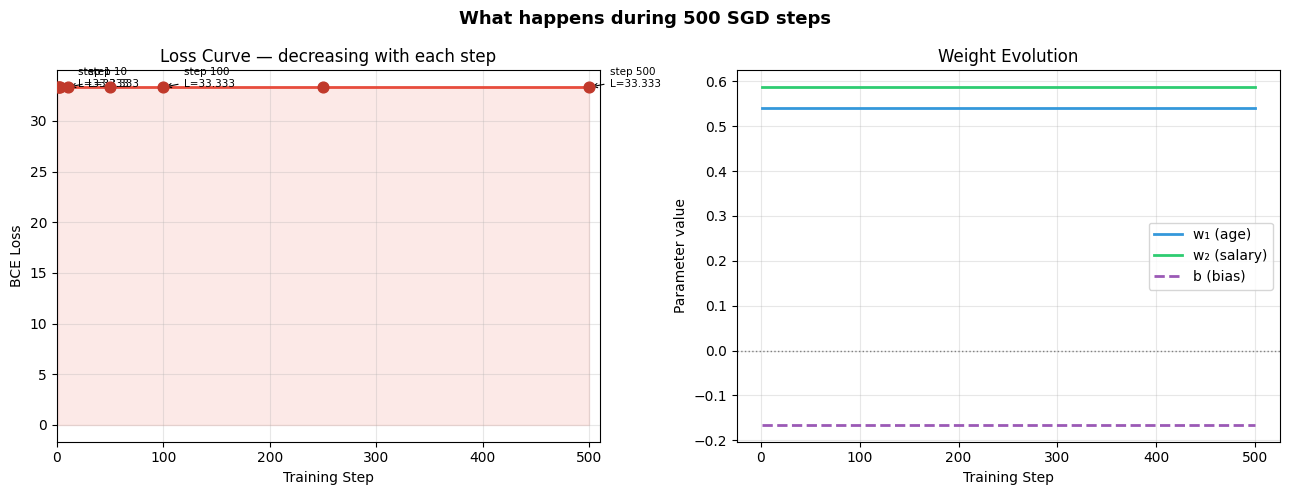

In [65]:
wh    = np.array(weight_history)
steps = np.arange(1, 501)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax = axes[0]
ax.plot(steps, loss_history, color='#e74c3c', lw=2)
ax.fill_between(steps, loss_history, alpha=0.12, color='#e74c3c')
for sk, (lv, w1v, w2v, bv) in snapshots.items():
    ax.scatter(sk+1, lv, s=60, zorder=5, color='#c0392b')
    if sk in [0, 9, 99, 499]:
        ax.annotate(f'step {sk+1}\nL={lv:.3f}', xy=(sk+1, lv),
                    xytext=(sk+20, lv+0.03), fontsize=7.5,
                    arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set(xlabel='Training Step', ylabel='BCE Loss',
       title='Loss Curve — decreasing with each step', xlim=(0,510))
ax.grid(True, alpha=0.3)

# Weights
ax = axes[1]
ax.plot(steps, wh[:,0], color='#3498db', lw=2, label='w₁ (age)')
ax.plot(steps, wh[:,1], color='#2ecc71', lw=2, label='w₂ (salary)')
ax.plot(steps, wh[:,2], color='#9b59b6', lw=2, ls='--', label='b (bias)')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set(xlabel='Training Step', ylabel='Parameter value', title='Weight Evolution')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('What happens during 500 SGD steps', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Final Predictions vs Ground Truth

In [68]:
model.eval()
with torch.no_grad():
    preds_after = model(inputs)

print('Predictions AFTER 500 training steps:')
print(f'{"#":>3}  {"age":>4}  {"salary":>7}  {"y":>4}  {"ŷ":>8}  {"class":>6}  {"ok?"}')
print('-'*50)
correct = 0
for i in range(12):
    xi = inputs[i].numpy(); yi = labels[i].item(); yh = preds_after[i].item()
    pc = 1 if yh > 0.5 else 0
    ok = '✅' if pc==int(yi) else '❌'
    if pc==int(yi): correct += 1
    print(f'{i+1:>3}  {xi[0]:>4.0f}  {xi[1]:>7.0f}  {yi:>4.0f}  {yh:>8.4f}  {pc:>6}  {ok}')

loss_after = criterion(preds_after, labels).item()
print(f'\n  Loss:     {loss_after:.6f}  (was {criterion(torch.tensor([[0.5]]*12), labels).item():.6f} at random)')
print(f'  Accuracy: {correct}/12 = {correct/12*100:.1f}%')

Predictions AFTER 500 training steps:
  #   age   salary     y         ŷ   class  ok?
--------------------------------------------------
  1    22       25     0    1.0000       1  ❌
  2    25       35     0    1.0000       1  ❌
  3    47       80     1    1.0000       1  ✅
  4    52       95     1    1.0000       1  ✅
  5    46       82     1    1.0000       1  ✅
  6    56       90     1    1.0000       1  ✅
  7    23       27     0    1.0000       1  ❌
  8    30       50     1    1.0000       1  ✅
  9    40       60     1    1.0000       1  ✅
 10    39       47     0    1.0000       1  ❌
 11    53       95     1    1.0000       1  ✅
 12    48       88     1    1.0000       1  ✅

  Loss:     33.333332  (was 0.693147 at random)
  Accuracy: 8/12 = 66.7%
